In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
df = pd.read_csv('./../patient2025 - patient2025.csv')
df.head()

,HN,FBS,BMI,Diabetes,Chorestorol,age,hypertension,"vegetarian (1= yes, 0=no)",Marriage Status,Exercise (min/week),Living Area,stroke
0,11223,228.69,34.0,yes,201-220,71.0,1,1,Yes,0.0,Bangkok,1
1,8887,202.21,NaN,No,180-200,52.0,1,0,Yes,90.0,Country,1
2,5666,105.92,30.5,yes,180-200,78.0,1,1,Yes,0.0,Country,1
3,460182,171.23,35.0,No,221-260,54.0,1,0,Yes,0.0,Bangkok,1
4,166665,174.12,28.0,No,180-200,79.0,1,0,Yes,90.0,Country,1


# Clean Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   HN                         1000 non-null   int64  
 1   FBS                        1000 non-null   float64
 2   BMI                        940 non-null    float64
 3   Diabetes                   1000 non-null   object 
 4   Chorestorol                1000 non-null   object 
 5   age                        1000 non-null   float64
 6   hypertension               1000 non-null   int64  
 7   vegetarian (1= yes, 0=no)  1000 non-null   int64  
 8   Marriage Status            1000 non-null   object 
 9   Exercise (min/week)        974 non-null    float64
 10  Living Area                1000 non-null   object 
 11  stroke                     1000 non-null   int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 93.9+ KB


### Drop NaN

In [4]:
df = df.fillna(0)
df

,HN,FBS,BMI,Diabetes,Chorestorol,age,hypertension,"vegetarian (1= yes, 0=no)",Marriage Status,Exercise (min/week),Living Area,stroke
0,11223,228.69,34.0,yes,201-220,71.00,1,1,Yes,0.0,Bangkok,1
1,8887,202.21,0.0,No,180-200,52.00,1,0,Yes,90.0,Country,1
2,5666,105.92,30.5,yes,180-200,78.00,1,1,Yes,0.0,Country,1
3,460182,171.23,35.0,No,221-260,54.00,1,0,Yes,0.0,Bangkok,1
4,166665,174.12,28.0,No,180-200,79.00,1,0,Yes,90.0,Country,1
...,...,...,...,...,...,...,...,...,...,...,...,...
995,60211,90.51,18.9,yes,Unknown,1.40,0,0,No,120.0,Bangkok,0
996,53279,118.87,16.3,yes,Unknown,0.24,0,0,No,120.0,Country,0
997,61715,56.42,31.8,yes,180-200,55.00,0,0,Yes,0.0,Country,0
998,37830,73.67,21.0,No,Unknown,29.00,0,0,No,0.0,Bangkok,0


### Normalize Chorestorol

In [5]:
df.loc[df['Chorestorol'] == 'Unknown', 'Chorestorol'] = '0-0'
df['Chorestorol'] = df['Chorestorol'].str.split('-')
df['Chorestorol'] = (df['Chorestorol'].str[0].astype(int) + df['Chorestorol'].str[1].astype(int)) / 2 

df

,HN,FBS,BMI,Diabetes,Chorestorol,age,hypertension,"vegetarian (1= yes, 0=no)",Marriage Status,Exercise (min/week),Living Area,stroke
0,11223,228.69,34.0,yes,210.5,71.00,1,1,Yes,0.0,Bangkok,1
1,8887,202.21,0.0,No,190.0,52.00,1,0,Yes,90.0,Country,1
2,5666,105.92,30.5,yes,190.0,78.00,1,1,Yes,0.0,Country,1
3,460182,171.23,35.0,No,240.5,54.00,1,0,Yes,0.0,Bangkok,1
4,166665,174.12,28.0,No,190.0,79.00,1,0,Yes,90.0,Country,1
...,...,...,...,...,...,...,...,...,...,...,...,...
995,60211,90.51,18.9,yes,0.0,1.40,0,0,No,120.0,Bangkok,0
996,53279,118.87,16.3,yes,0.0,0.24,0,0,No,120.0,Country,0
997,61715,56.42,31.8,yes,190.0,55.00,0,0,Yes,0.0,Country,0
998,37830,73.67,21.0,No,0.0,29.00,0,0,No,0.0,Bangkok,0


### Normalize Diabetes

In [6]:
df.loc[df['Diabetes'] == 'yes', 'Diabetes'] = 1
df.loc[df['Diabetes'] == 'No', 'Diabetes'] = 0

df

,HN,FBS,BMI,Diabetes,Chorestorol,age,hypertension,"vegetarian (1= yes, 0=no)",Marriage Status,Exercise (min/week),Living Area,stroke
0,11223,228.69,34.0,1,210.5,71.00,1,1,Yes,0.0,Bangkok,1
1,8887,202.21,0.0,0,190.0,52.00,1,0,Yes,90.0,Country,1
2,5666,105.92,30.5,1,190.0,78.00,1,1,Yes,0.0,Country,1
3,460182,171.23,35.0,0,240.5,54.00,1,0,Yes,0.0,Bangkok,1
4,166665,174.12,28.0,0,190.0,79.00,1,0,Yes,90.0,Country,1
...,...,...,...,...,...,...,...,...,...,...,...,...
995,60211,90.51,18.9,1,0.0,1.40,0,0,No,120.0,Bangkok,0
996,53279,118.87,16.3,1,0.0,0.24,0,0,No,120.0,Country,0
997,61715,56.42,31.8,1,190.0,55.00,0,0,Yes,0.0,Country,0
998,37830,73.67,21.0,0,0.0,29.00,0,0,No,0.0,Bangkok,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   HN                         1000 non-null   int64  
 1   FBS                        1000 non-null   float64
 2   BMI                        1000 non-null   float64
 3   Diabetes                   1000 non-null   object 
 4   Chorestorol                1000 non-null   float64
 5   age                        1000 non-null   float64
 6   hypertension               1000 non-null   int64  
 7   vegetarian (1= yes, 0=no)  1000 non-null   int64  
 8   Marriage Status            1000 non-null   object 
 9   Exercise (min/week)        1000 non-null   float64
 10  Living Area                1000 non-null   object 
 11  stroke                     1000 non-null   int64  
dtypes: float64(5), int64(4), object(3)
memory usage: 93.9+ KB


# Start KNN

### Select Features and Class

In [8]:
features = ['FBS', 'BMI', 'Diabetes', 'Chorestorol', 'age', 'hypertension', 'vegetarian (1= yes, 0=no)', 'Exercise (min/week)']
df[features].head(5)

,FBS,BMI,Diabetes,Chorestorol,age,hypertension,"vegetarian (1= yes, 0=no)",Exercise (min/week)
0,228.69,34.0,1,210.5,71.0,1,1,0.0
1,202.21,0.0,0,190.0,52.0,1,0,90.0
2,105.92,30.5,1,190.0,78.0,1,1,0.0
3,171.23,35.0,0,240.5,54.0,1,0,0.0
4,174.12,28.0,0,190.0,79.0,1,0,90.0


In [9]:
df['stroke'].head(5)

0    1
1    1
2    1
3    1
4    1
Name: stroke, dtype: int64

### Start Training

In [10]:
X = df[features].values
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)

### Select the optimal K

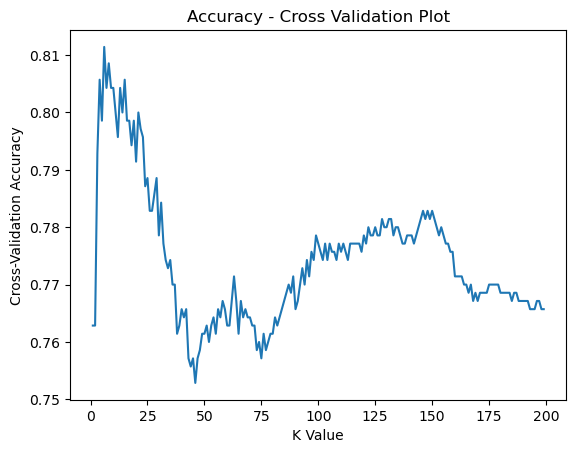

In [11]:
k_values = range(1, 200)
k_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors = k, weights = 'distance')
    score = cross_val_score(knn, X_train, y_train, cv = 10, scoring = 'accuracy')
    k_scores.append(score.mean())

plt.plot(k_values, k_scores)
plt.xlabel('K Value')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Accuracy - Cross Validation Plot')
plt.show()

In [12]:
optimal_k = [k_values[i] for i in range(len(k_scores)) if k_scores[i] == max(k_scores)][0]
optimal_k

6

### Start classification

In [13]:
knn = KNeighborsClassifier(n_neighbors = optimal_k, weights = 'distance')
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.7633333333333333
